05_visualização.ipynb

1. Importação das bibliotecas
2. Carregamento dos dados
3. Distribuição da variável-alvo
4. Distribuição das características
5. Carga emocional
6. Relação entre características e possíveis golpes
7. Correlação das características
8. Visualizações dos resultados dos modelos
9. Comparação final dos modelos

| Gráfico                   | O que mostra                                            | Importância |
|---------------------------|---------------------------------------------------------|-------------|
| Distribuição do target    | Golpe × Não golpe                                       | ⭐⭐⭐⭐⭐       |
| Distribuição das features | Quantas mensagens possuem cada característica           | ⭐⭐⭐⭐        |
| Carga emocional           | Baixo × Médio × Alto                                    | ⭐⭐⭐         |
| Correlação das features   | Relação entre características e `Possivel golpe`        | ⭐⭐⭐⭐⭐       |
| Features × target         | Quais características aparecem mais em possíveis golpes | ⭐⭐⭐⭐⭐       |

Após treinar modelos é possivel gerar graficos a seguir:


| Gráfico                  | O que mostra                                          |
| ------------------------ | ----------------------------------------------------- |
| Accuracy                 | Desempenho geral                                      |
| Precision                | Quantos classificados como golpe realmente eram golpe |
| Recall                   | Quantos golpes o modelo conseguiu encontrar           |
| F1-score                 | Equilíbrio entre Precision e Recall                   |
| Matriz de confusão       | Acertos e erros                                       |
| Comparação dos modelos   | Qual modelo teve melhor desempenho                    |
| Curva ROC                | Capacidade de separação                               |
| AUC                      | Qualidade da separação                                |
| Importância das features | Quais características mais influenciaram o modelo     |

Importar as bibliotecas

In [1]:
# Importa a biblioteca Pandas para manipulação dos dados.
import pandas as pd

# Importa a biblioteca NumPy para operações numéricas.
import numpy as np

# Importa a biblioteca Matplotlib para criação de gráficos.
import matplotlib.pyplot as plt

# Importa a biblioteca Seaborn para criação de gráficos estatísticos.
import seaborn as sns

Carregar o dataset

In [2]:
# Define o caminho relativo para o dataset original.
caminho_dataset = "../data/raw/DATASET - Dataset_limpo_V1.csv"

# Carrega o arquivo CSV para um DataFrame chamado df.
df = pd.read_csv(caminho_dataset)

# Exibe as cinco primeiras linhas para confirmar que o dataset foi carregado corretamente.
df.head()

,Mensagem,solicita_senha,solicita_codigo_autenticacao,solicita_dados_bancarios,solicita_dados_pessoais,solicita_dados_cartao,solicita_atualizacao_cadastro,solicita_pagamento,solicita_clique,solicita_ligacao,...,possui_reembolso,possui_vantagem_inesperada,possui_oferta_financeira,possui_url,possui_url_encurtada,possui_telefone,possui_pix,possui_erros_ortografia_gramatica,possui_chamada_acao,possivel_golpe
0,Sabia que da pra curtir tudo da Claro? 350 MEG...,0,0,0,0,0,0,0,1,1,...,0,0,1,1,1,1,0,1,1,0
1,Seu dia a dia pede MUITA INTERNET! Entao vem p...,0,0,0,0,0,0,0,1,0,...,0,0,1,1,1,0,0,1,1,0
2,"Cliente Claro,nao identificamos pgt fat do ser...",0,0,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,1,1,0
3,Claro Multi ta na sua com oferta especial: 600...,0,0,0,0,0,0,0,1,1,...,0,0,1,1,1,1,0,1,1,0
4,Claro Multi ta na sua com oferta especial: 600...,0,0,0,0,0,0,0,1,1,...,0,0,1,1,1,1,0,1,1,0


Distribuição do target

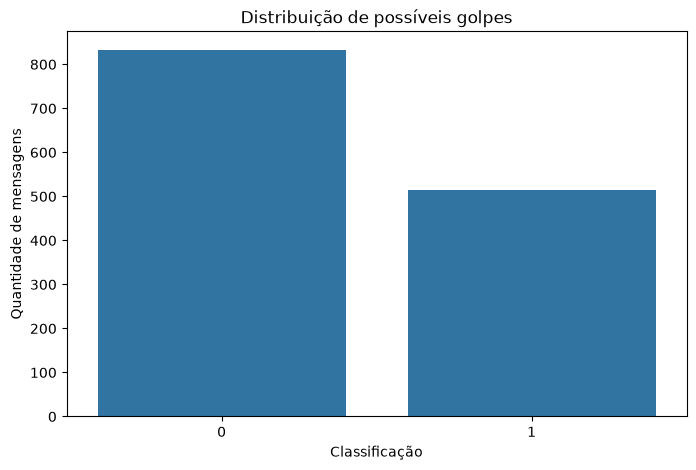

In [4]:
# Cria uma figura com tamanho adequado para visualização.
plt.figure(figsize=(8, 5))

# Cria um gráfico de barras com a quantidade de mensagens em cada classe.
sns.countplot(data=df, x="possivel_golpe")

# Define o título do gráfico.
plt.title("Distribuição de possíveis golpes")

# Define o nome do eixo horizontal.
plt.xlabel("Classificação")

# Define o nome do eixo vertical.
plt.ylabel("Quantidade de mensagens")

# Exibe o gráfico.
plt.show()

Distribuição das features

Quais características aparecem com maior frequência nas mensagens do nosso dataset?

Definir as features

In [5]:
# Define as características estruturadas que serão analisadas nos gráficos.
colunas_features = [
    "solicita_senha",
    "solicita_codigo_autenticacao",
    "solicita_dados_bancarios",
    "solicita_dados_pessoais",
    "solicita_dados_cartao",
    "solicita_atualizacao_cadastro",
    "solicita_pagamento",
    "solicita_clique",
    "solicita_ligacao",
    "menciona_bloqueio_conta",
    "possui_urgencia",
    "possui_ameaca",
    "possui_linguagem_alarmista",
    "possui_recompensa",
    "possui_reembolso",
    "possui_vantagem_inesperada",
    "possui_oferta_financeira",
    "possui_url",
    "possui_url_encurtada",
    "possui_telefone",
    "possui_pix",
    "possui_erros_ortografia_gramatica",
    "possui_chamada_acao"
]

Calcular a quantidade de ocorrências
0 = característica não identificada
1 = característica identificada

In [6]:
# Soma os valores de cada característica para descobrir quantas mensagens possuem cada sinal.
quantidade_features = df[colunas_features].sum()

# Ordena as características da menor para a maior quantidade de ocorrências.
quantidade_features = quantidade_features.sort_values(ascending=True)

# Exibe a quantidade de ocorrências de cada característica.
print(quantidade_features)

solicita_dados_bancarios              16
possui_reembolso                      18
solicita_dados_cartao                 35
solicita_senha                        35
solicita_atualizacao_cadastro         72
solicita_dados_pessoais               73
possui_pix                           108
solicita_ligacao                     114
possui_telefone                      121
possui_recompensa                    122
solicita_codigo_autenticacao         136
possui_vantagem_inesperada           157
possui_url_encurtada                 185
menciona_bloqueio_conta              191
possui_ameaca                        194
solicita_pagamento                   268
possui_oferta_financeira             285
possui_linguagem_alarmista           406
possui_urgencia                      507
possui_erros_ortografia_gramatica    534
solicita_clique                      574
possui_url                           579
possui_chamada_acao                  847
dtype: int64


Criar o gráfico

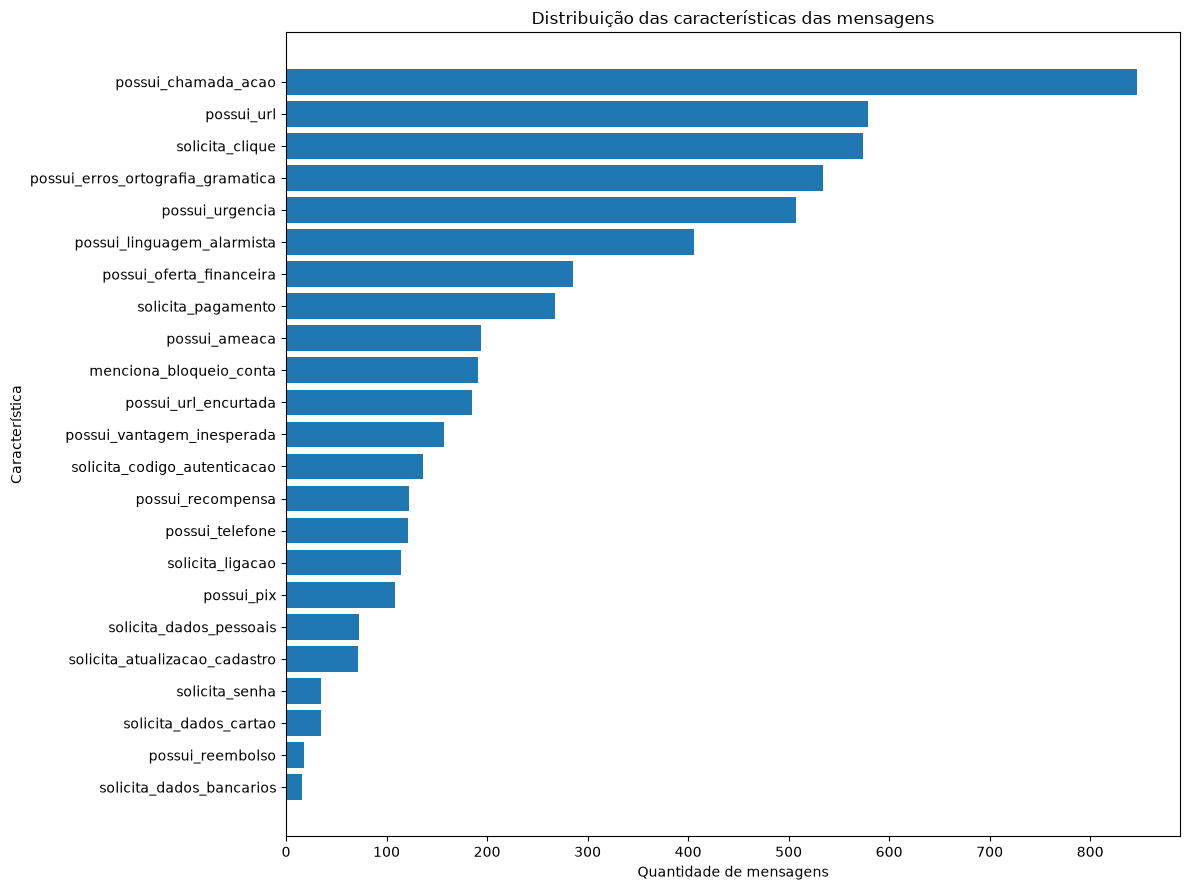

In [7]:
# Cria uma figura com tamanho adequado para acomodar todas as características.
plt.figure(figsize=(12, 9))

# Cria um gráfico de barras horizontais utilizando a quantidade de cada característica.
plt.barh(quantidade_features.index, quantidade_features.values)

# Define o título do gráfico.
plt.title("Distribuição das características das mensagens")

# Define o nome do eixo horizontal.
plt.xlabel("Quantidade de mensagens")

# Define o nome do eixo vertical.
plt.ylabel("Característica")

# Ajusta automaticamente os elementos do gráfico para evitar cortes.
plt.tight_layout()

# Exibe o gráfico.
plt.show()

Carga emocional

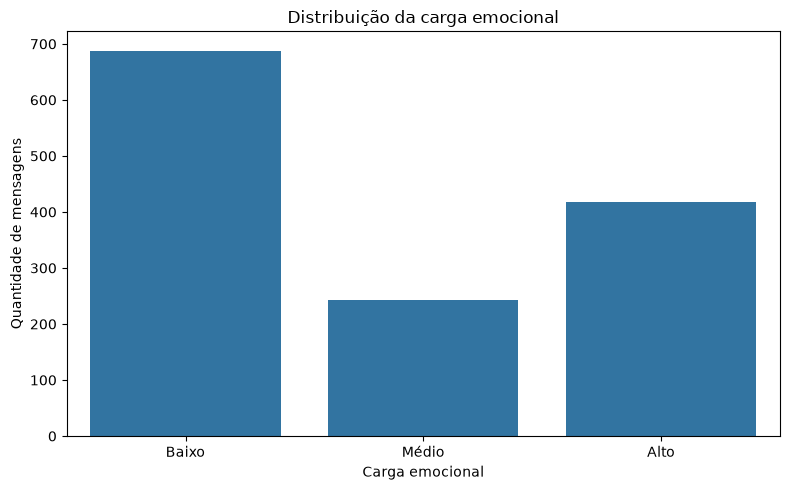

In [8]:
# Cria uma figura adequada para o gráfico de carga emocional.
plt.figure(figsize=(8, 5))

# Cria um gráfico de barras com a quantidade de mensagens em cada nível emocional.
sns.countplot(data=df, x="carga_emocional", order=["Baixo", "Médio", "Alto"])

# Define o título do gráfico.
plt.title("Distribuição da carga emocional")

# Define o nome do eixo horizontal.
plt.xlabel("Carga emocional")

# Define o nome do eixo vertical.
plt.ylabel("Quantidade de mensagens")

# Ajusta os elementos do gráfico.
plt.tight_layout()

# Exibe o gráfico.
plt.show()

Correlação das features

Quais características possuem maior relação com Possivel golpe?

In [10]:
# Cria uma cópia contendo somente as features estruturadas e a variável-alvo.
dados_correlacao = df[colunas_features + ["possivel_golpe"]].copy()

# Calcula a correlação entre todas as características selecionadas.
matriz_correlacao = dados_correlacao.corr()

# Obtém somente as correlações de cada característica com a variável-alvo.
correlacao_target = matriz_correlacao["possivel_golpe"].sort_values(ascending=False)

# Exibe as correlações ordenadas.
print(correlacao_target)

possivel_golpe                       1.000000
possui_linguagem_alarmista           0.696318
possui_urgencia                      0.670424
possui_chamada_acao                  0.565576
menciona_bloqueio_conta              0.499939
possui_ameaca                        0.491720
solicita_clique                      0.410928
possui_url                           0.401502
possui_vantagem_inesperada           0.357623
possui_pix                           0.297067
solicita_dados_pessoais              0.264230
solicita_atualizacao_cadastro        0.261753
possui_recompensa                    0.236674
solicita_dados_cartao                0.207926
possui_oferta_financeira             0.206723
solicita_senha                       0.198319
solicita_pagamento                   0.167420
possui_reembolso                     0.134845
solicita_dados_bancarios             0.111364
solicita_ligacao                    -0.002751
possui_telefone                     -0.006265
solicita_codigo_autenticacao      

Gerar Gráfico

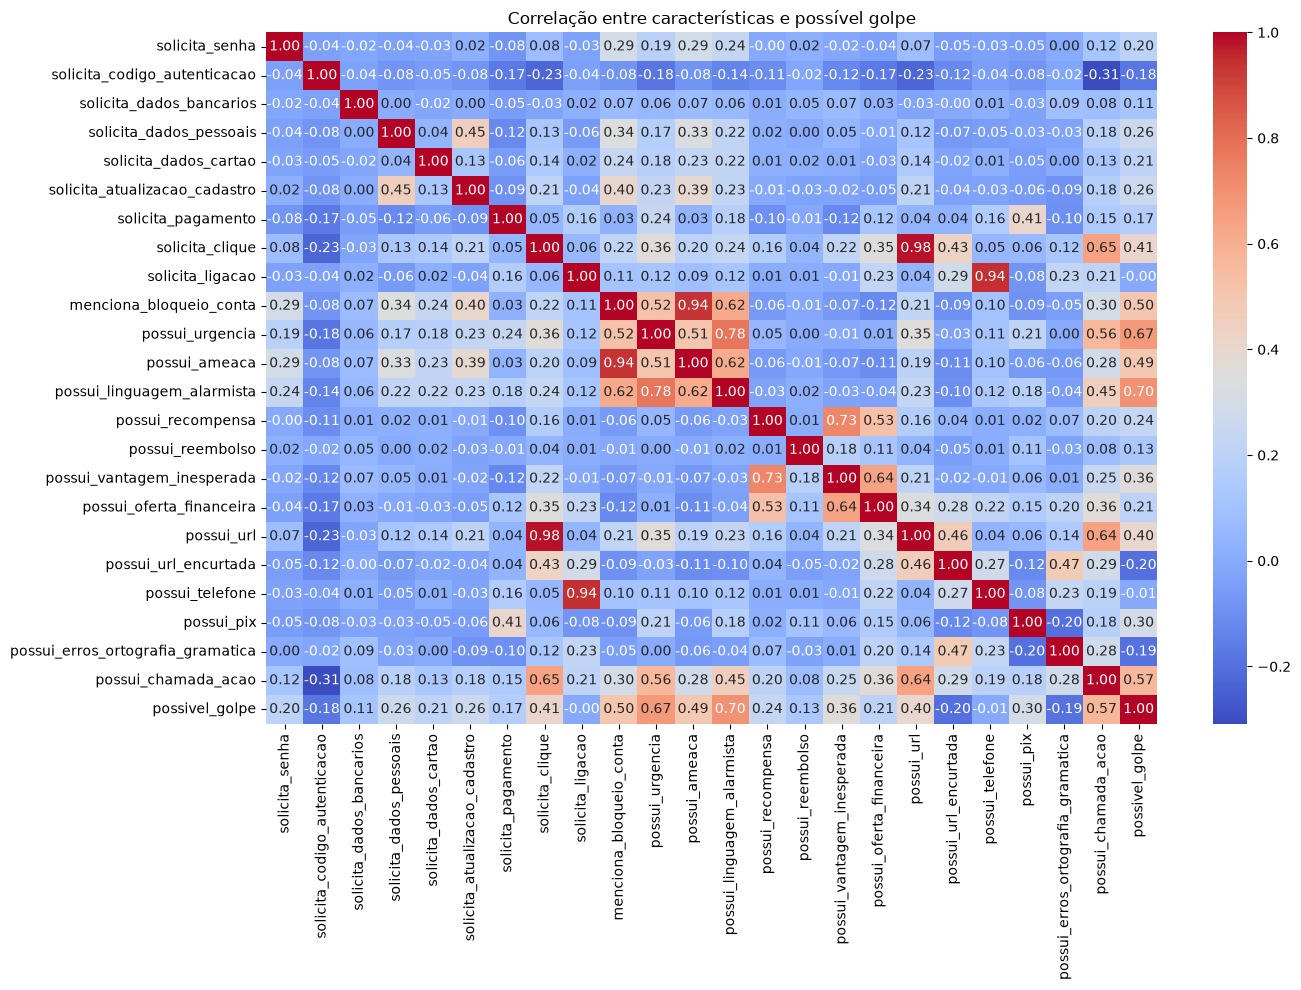

In [11]:
# Cria uma figura grande para facilitar a leitura da matriz.
plt.figure(figsize=(14, 10))

# Cria um mapa de calor utilizando a matriz de correlação.
sns.heatmap(matriz_correlacao, annot=True, fmt=".2f", cmap="coolwarm")

# Define o título do mapa de calor.
plt.title("Correlação entre características e possível golpe")

# Ajusta os elementos do gráfico.
plt.tight_layout()

# Exibe o gráfico.
plt.show()

Features × target

Quando uma determinada característica aparece, ela aparece mais em mensagens de golpe ou de não golpe?

In [13]:
# Cria uma lista vazia para armazenar os resultados das características.
resultados_features_target = []

# Percorre todas as características selecionadas para análise.
for coluna in colunas_features:
    
    # Cria uma tabela cruzada entre a característica e a variável-alvo.
    tabela = pd.crosstab(df[coluna], df["possivel_golpe"])
    
    # Obtém a quantidade de mensagens com a característica que não são golpes.
    nao_golpe = tabela.loc[1, 0] if 1 in tabela.index and 0 in tabela.columns else 0
    
    # Obtém a quantidade de mensagens com a característica que são possíveis golpes.
    possivel_golpe = tabela.loc[1, 1] if 1 in tabela.index and 1 in tabela.columns else 0
    
    # Adiciona os resultados da característica à lista.
    resultados_features_target.append({
        "feature": coluna,
        "nao_golpe": nao_golpe,
        "possivel_golpe": possivel_golpe
    })

# Converte a lista de resultados em um DataFrame.
df_features_target = pd.DataFrame(resultados_features_target)

# Exibe a tabela com os resultados.
df_features_target

,feature,nao_golpe,possivel_golpe
0,solicita_senha,1,34
1,solicita_codigo_autenticacao,119,17
2,solicita_dados_bancarios,2,14
3,solicita_dados_pessoais,6,67
4,solicita_dados_cartao,0,35
5,solicita_atualizacao_cadastro,6,66
6,solicita_pagamento,122,146
7,solicita_clique,222,352
8,solicita_ligacao,71,43
9,menciona_bloqueio_conta,4,187


Gerar gráfico

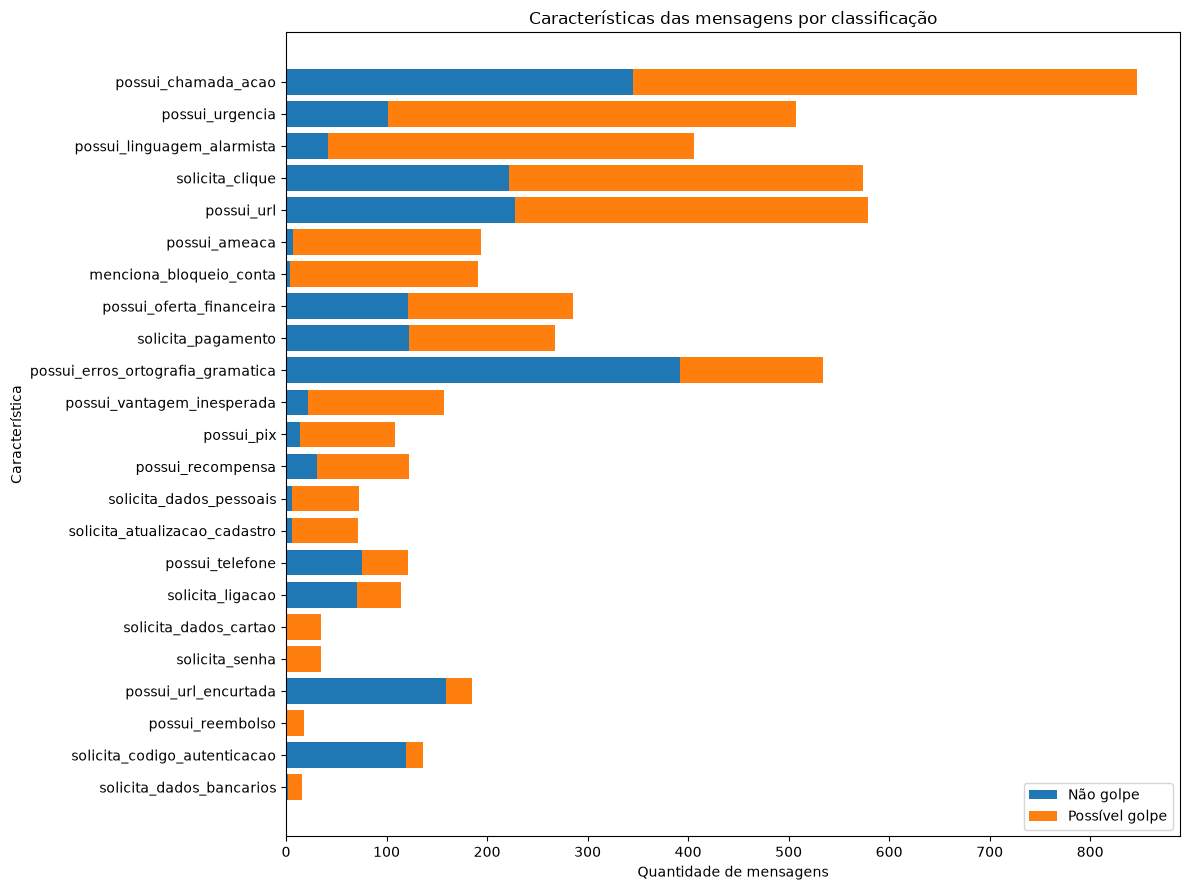

In [14]:
# Ordena as características pela quantidade de possíveis golpes.
df_features_target = df_features_target.sort_values("possivel_golpe", ascending=True)

# Cria uma figura grande para acomodar todas as características.
plt.figure(figsize=(12, 9))

# Cria as barras das mensagens classificadas como não golpe.
plt.barh(df_features_target["feature"], df_features_target["nao_golpe"], label="Não golpe")

# Cria as barras das mensagens classificadas como possível golpe.
plt.barh(df_features_target["feature"], df_features_target["possivel_golpe"], left=df_features_target["nao_golpe"], label="Possível golpe")

# Define o título do gráfico.
plt.title("Características das mensagens por classificação")

# Define o nome do eixo horizontal.
plt.xlabel("Quantidade de mensagens")

# Define o nome do eixo vertical.
plt.ylabel("Característica")

# Exibe a legenda das classificações.
plt.legend()

# Ajusta os elementos do gráfico.
plt.tight_layout()

# Exibe o gráfico.
plt.show()

Melhorando graficos

In [15]:
# Importa a biblioteca os para trabalhar com pastas e caminhos de arquivos.
import os

# Define o caminho da pasta onde os gráficos serão armazenados.
pasta_graficos = "../reports/figures"

# Cria a pasta de gráficos caso ela ainda não exista.
os.makedirs(pasta_graficos, exist_ok=True)

C:\Users\blima\AppData\Local\Temp\ipykernel_33740\2654996688.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Não golpe", "possível_golpe"])


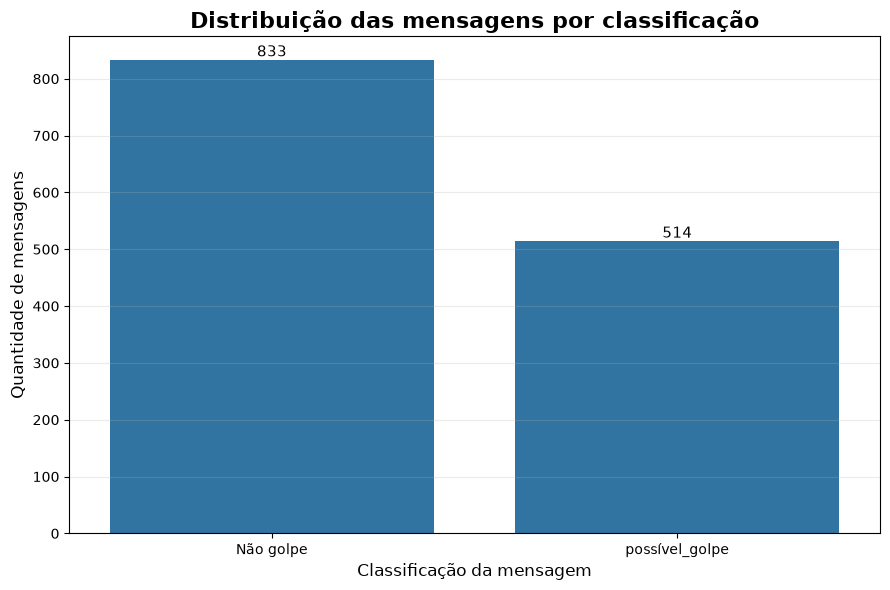

In [18]:
# Cria uma figura com dimensões adequadas para apresentação.
plt.figure(figsize=(9, 6))

# Cria o gráfico de barras com a quantidade de mensagens por classificação.
ax = sns.countplot(data=df, x="possivel_golpe")

# Define um título descritivo para o gráfico.
plt.title("Distribuição das mensagens por classificação", fontsize=16, fontweight="bold")

# Define o nome do eixo horizontal.
plt.xlabel("Classificação da mensagem", fontsize=12)

# Define o nome do eixo vertical.
plt.ylabel("Quantidade de mensagens", fontsize=12)

# Define os nomes mais amigáveis das categorias no eixo horizontal.
ax.set_xticklabels(["Não golpe", "possível_golpe"])

# Percorre as barras existentes no gráfico.
for barra in ax.patches:
    
    # Obtém a altura da barra, que representa a quantidade de mensagens.
    quantidade = int(barra.get_height())
    
    # Adiciona o valor da quantidade acima da respectiva barra.
    ax.annotate(
        str(quantidade),
        (barra.get_x() + barra.get_width() / 2, quantidade),
        ha="center",
        va="bottom",
        fontsize=11
    )

# Remove as linhas verticais do gráfico para deixá-lo visualmente mais limpo.
ax.grid(axis="x", visible=False)

# Adiciona linhas horizontais suaves para facilitar a comparação das quantidades.
ax.grid(axis="y", alpha=0.25)

# Ajusta automaticamente os elementos do gráfico.
plt.tight_layout()

# Salva o gráfico em alta resolução na pasta de relatórios.
plt.savefig(f"{pasta_graficos}/01_distribuicao_target.png", dpi=300, bbox_inches="tight")

# Exibe o gráfico no notebook.
plt.show()

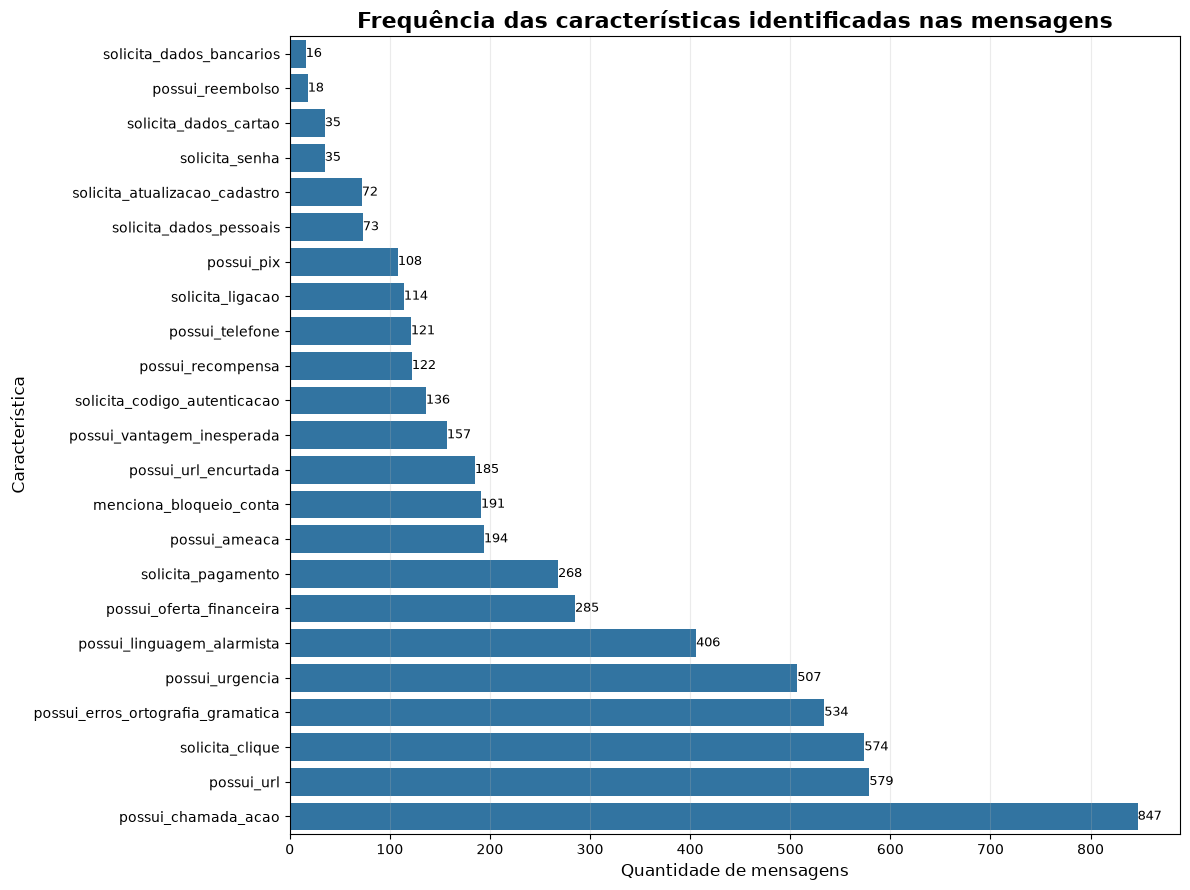

In [19]:
# Cria uma figura com dimensões adequadas para acomodar todas as características.
plt.figure(figsize=(12, 9))

# Cria um gráfico de barras horizontais com as características ordenadas por frequência.
ax = sns.barplot(
    x=quantidade_features.values,
    y=quantidade_features.index
)

# Define o título do gráfico.
plt.title("Frequência das características identificadas nas mensagens", fontsize=16, fontweight="bold")

# Define o nome do eixo horizontal.
plt.xlabel("Quantidade de mensagens", fontsize=12)

# Define o nome do eixo vertical.
plt.ylabel("Característica", fontsize=12)

# Percorre todas as barras do gráfico.
for barra in ax.patches:
    
    # Obtém o valor representado pela barra.
    quantidade = int(barra.get_width())
    
    # Adiciona o valor no final de cada barra.
    ax.annotate(
        str(quantidade),
        (quantidade, barra.get_y() + barra.get_height() / 2),
        ha="left",
        va="center",
        fontsize=9
    )

# Adiciona linhas horizontais suaves para facilitar a comparação dos valores.
ax.grid(axis="x", alpha=0.25)

# Remove as linhas horizontais desnecessárias do gráfico.
ax.grid(axis="y", visible=False)

# Ajusta automaticamente os elementos do gráfico.
plt.tight_layout()

# Salva o gráfico em alta resolução.
plt.savefig(f"{pasta_graficos}/02_distribuicao_features.png", dpi=300, bbox_inches="tight")

# Exibe o gráfico no notebook.
plt.show()

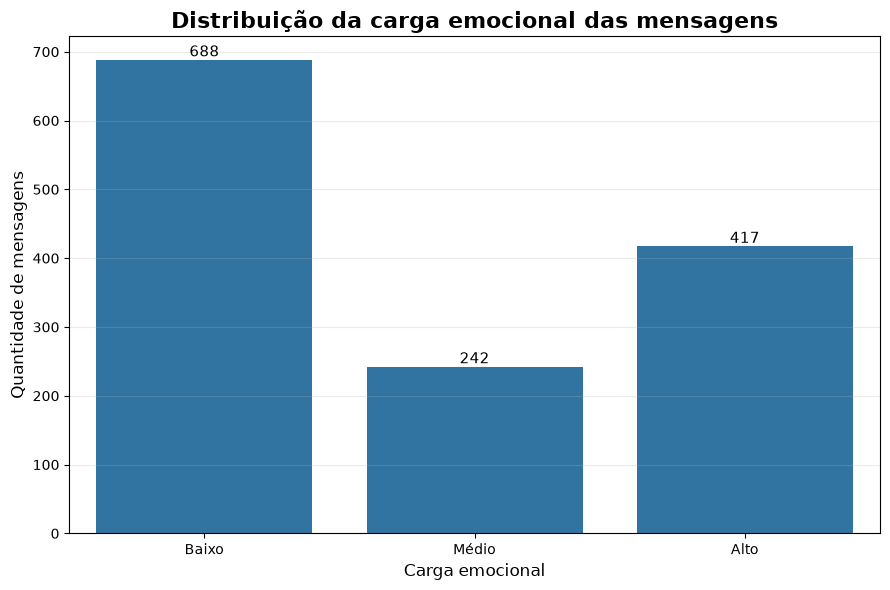

In [20]:
# Cria uma figura adequada para o gráfico de carga emocional.
plt.figure(figsize=(9, 6))

# Cria o gráfico de barras mantendo a ordem lógica da carga emocional.
ax = sns.countplot(
    data=df,
    x="carga_emocional",
    order=["Baixo", "Médio", "Alto"]
)

# Define o título do gráfico.
plt.title("Distribuição da carga emocional das mensagens", fontsize=16, fontweight="bold")

# Define o nome do eixo horizontal.
plt.xlabel("Carga emocional", fontsize=12)

# Define o nome do eixo vertical.
plt.ylabel("Quantidade de mensagens", fontsize=12)

# Percorre as barras do gráfico.
for barra in ax.patches:
    
    # Obtém a quantidade representada pela barra.
    quantidade = int(barra.get_height())
    
    # Adiciona o valor acima da barra.
    ax.annotate(
        str(quantidade),
        (barra.get_x() + barra.get_width() / 2, quantidade),
        ha="center",
        va="bottom",
        fontsize=11
    )

# Adiciona linhas horizontais suaves para facilitar a leitura.
ax.grid(axis="y", alpha=0.25)

# Remove as linhas verticais do gráfico.
ax.grid(axis="x", visible=False)

# Ajusta automaticamente os elementos do gráfico.
plt.tight_layout()

# Salva o gráfico em alta resolução.
plt.savefig(f"{pasta_graficos}/03_carga_emocional.png", dpi=300, bbox_inches="tight")

# Exibe o gráfico.
plt.show()

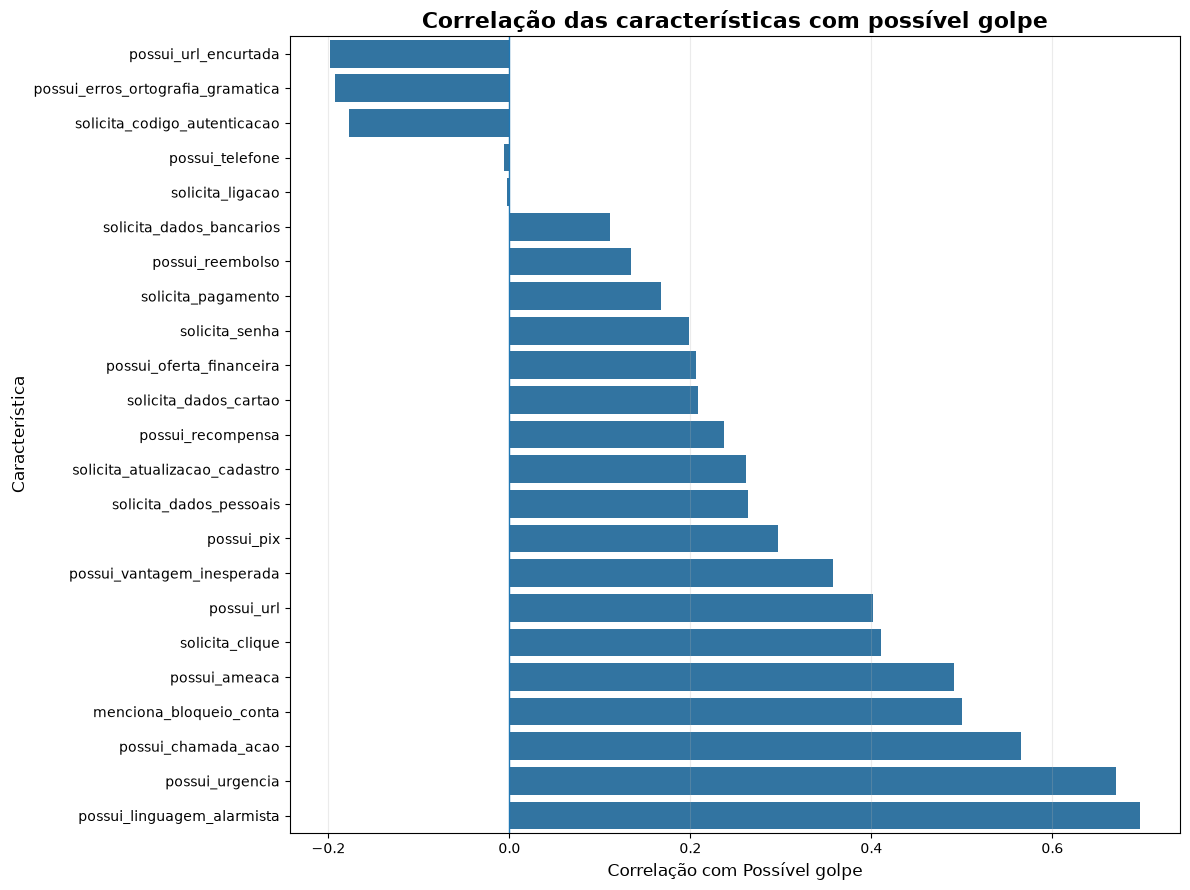

In [24]:
# Remove a variável-alvo da lista de correlações para analisar somente as características.
correlacao_features = correlacao_target.drop("possivel_golpe")

# Ordena as correlações da menor para a maior.
correlacao_features = correlacao_features.sort_values()

# Cria uma figura adequada para visualizar todas as correlações.
plt.figure(figsize=(12, 9))

# Cria um gráfico de barras horizontais com as correlações das características.
ax = sns.barplot(
    x=correlacao_features.values,
    y=correlacao_features.index
)

# Define o título do gráfico.
plt.title("Correlação das características com possível golpe", fontsize=16, fontweight="bold")

# Define o nome do eixo horizontal.
plt.xlabel("Correlação com Possível golpe", fontsize=12)

# Define o nome do eixo vertical.
plt.ylabel("Característica", fontsize=12)

# Adiciona uma linha vertical indicando correlação igual a zero.
plt.axvline(0, linewidth=1)

# Adiciona linhas horizontais suaves para facilitar a comparação.
ax.grid(axis="x", alpha=0.25)

# Remove as linhas horizontais desnecessárias.
ax.grid(axis="y", visible=False)

# Ajusta automaticamente os elementos do gráfico.
plt.tight_layout()

# Salva o gráfico em alta resolução.
plt.savefig(f"{pasta_graficos}/04_correlacao_features.png", dpi=300, bbox_inches="tight")

# Exibe o gráfico.
plt.show()

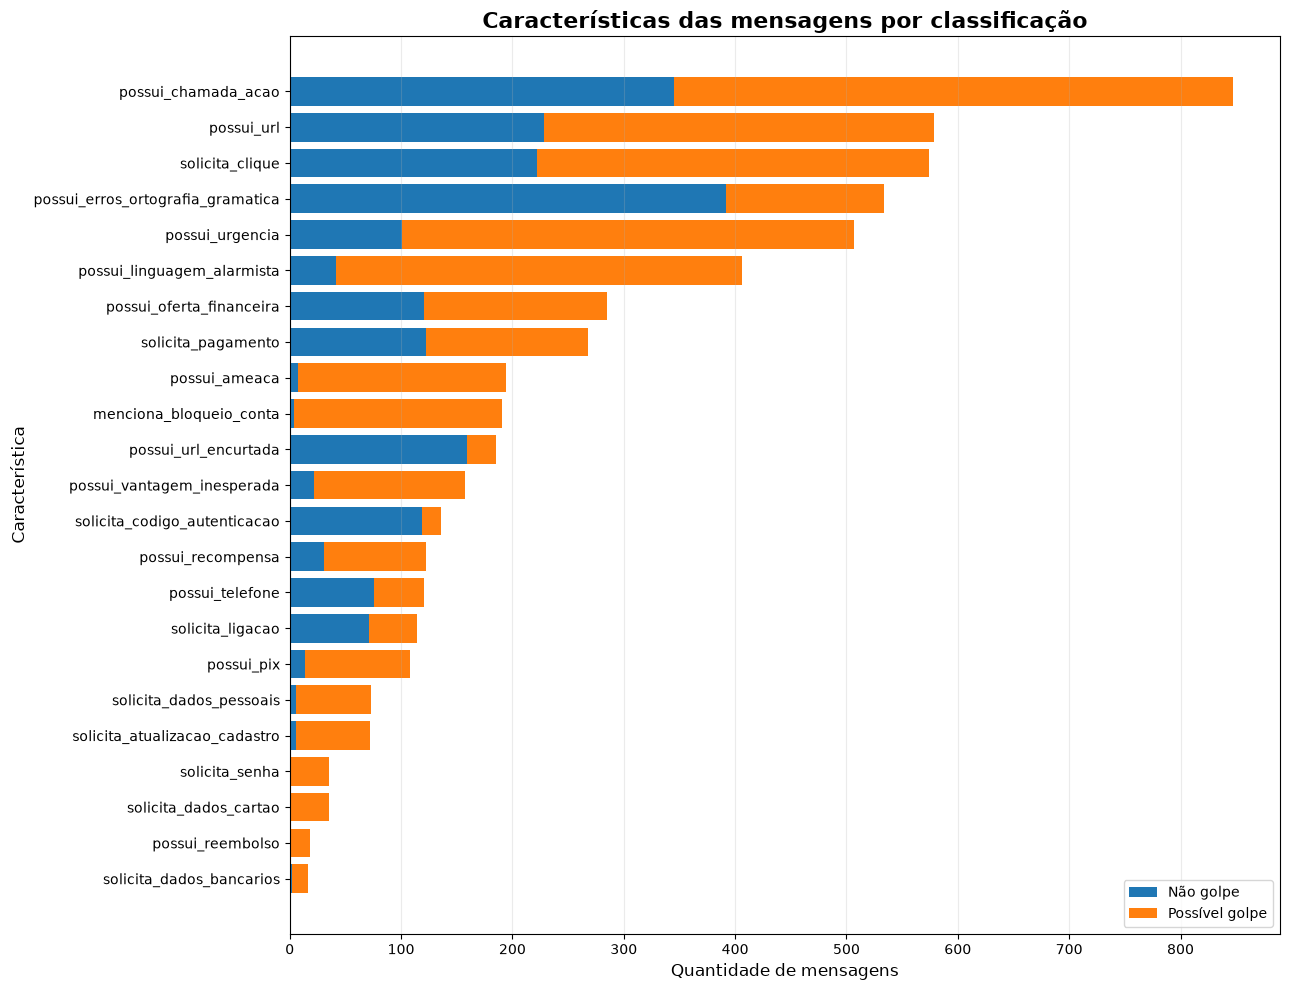

In [25]:
# Ordena as características pela quantidade total de mensagens com cada característica.
df_features_target["total"] = df_features_target["nao_golpe"] + df_features_target["possivel_golpe"]

# Ordena o DataFrame pela quantidade total de ocorrências.
df_features_target = df_features_target.sort_values("total", ascending=True)

# Cria uma figura grande para acomodar todas as características.
plt.figure(figsize=(13, 10))

# Cria as barras correspondentes às mensagens classificadas como não golpe.
ax = plt.barh(
    df_features_target["feature"],
    df_features_target["nao_golpe"],
    label="Não golpe"
)

# Cria as barras correspondentes às mensagens classificadas como possível golpe.
ax2 = plt.barh(
    df_features_target["feature"],
    df_features_target["possivel_golpe"],
    left=df_features_target["nao_golpe"],
    label="Possível golpe"
)

# Define o título do gráfico.
plt.title("Características das mensagens por classificação", fontsize=16, fontweight="bold")

# Define o nome do eixo horizontal.
plt.xlabel("Quantidade de mensagens", fontsize=12)

# Define o nome do eixo vertical.
plt.ylabel("Característica", fontsize=12)

# Exibe a legenda das duas classes.
plt.legend()

# Adiciona linhas horizontais suaves para facilitar a leitura.
plt.grid(axis="x", alpha=0.25)

# Ajusta automaticamente os elementos do gráfico.
plt.tight_layout()

# Salva o gráfico em alta resolução.
plt.savefig(f"{pasta_graficos}/05_features_por_target.png", dpi=300, bbox_inches="tight")

# Exibe o gráfico.
plt.show()

In [27]:
# Soma todas as características de risco de cada mensagem.
df["quantidade_sinais"] = df[colunas_features].sum(axis=1)

# Exibe algumas mensagens com a quantidade de sinais calculada.
df[["Mensagem", "quantidade_sinais", "possivel_golpe"]].head()

,Mensagem,quantidade_sinais,possivel_golpe
0,Sabia que da pra curtir tudo da Claro? 350 MEG...,8,0
1,Seu dia a dia pede MUITA INTERNET! Entao vem p...,6,0
2,"Cliente Claro,nao identificamos pgt fat do ser...",6,0
3,Claro Multi ta na sua com oferta especial: 600...,8,0
4,Claro Multi ta na sua com oferta especial: 600...,8,0


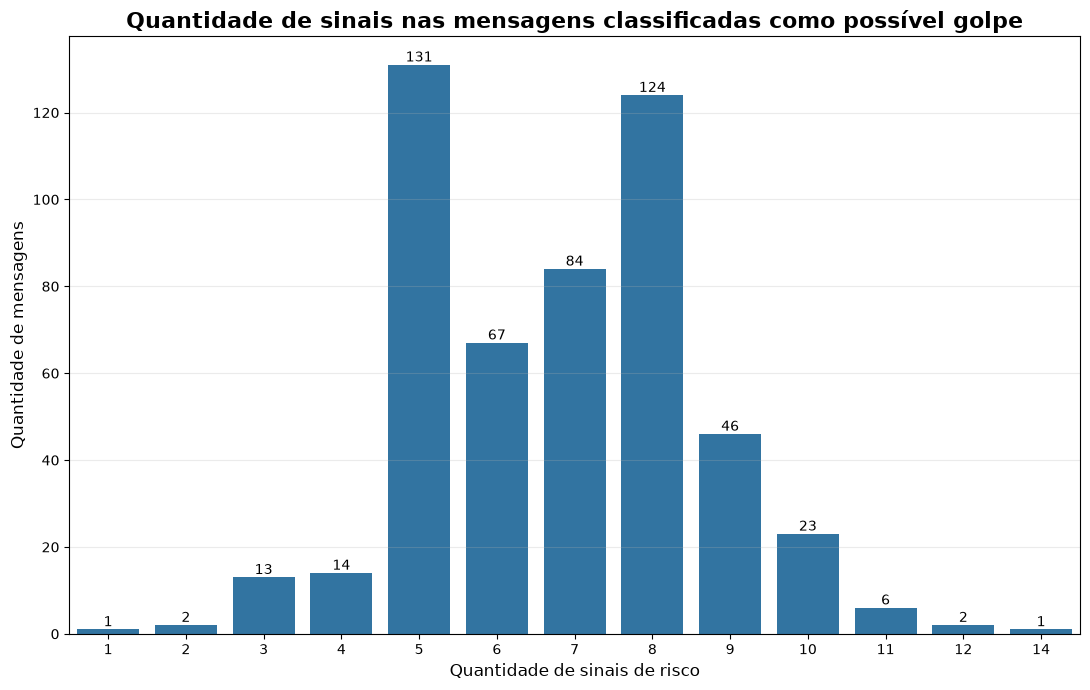

In [38]:
# Filtra somente as mensagens classificadas como possíveis golpes.
df_possiveis_golpes = df[df["possivel_golpe"] == 1].copy()

# Conta quantas mensagens de possível golpe existem para cada quantidade de sinais.
quantidade_sinais_golpes = df_possiveis_golpes["quantidade_sinais"].value_counts().sort_index()

# Cria uma figura com tamanho adequado para apresentação.
plt.figure(figsize=(11, 7))

# Cria um gráfico de barras mostrando a quantidade de mensagens por número de sinais.
ax = sns.barplot(
    x=quantidade_sinais_golpes.index,
    y=quantidade_sinais_golpes.values
)

# Define o título do gráfico.
plt.title(
    "Quantidade de sinais nas mensagens classificadas como possível golpe",
    fontsize=16,
    fontweight="bold"
)

# Define o nome do eixo horizontal.
plt.xlabel(
    "Quantidade de sinais de risco",
    fontsize=12
)

# Define o nome do eixo vertical.
plt.ylabel(
    "Quantidade de mensagens",
    fontsize=12
)

# Percorre todas as barras do gráfico.
for barra in ax.patches:
    
    # Obtém a quantidade representada pela barra.
    quantidade = int(barra.get_height())
    
    # Adiciona o valor acima da barra.
    ax.annotate(
        str(quantidade),
        (barra.get_x() + barra.get_width() / 2, quantidade),
        ha="center",
        va="bottom",
        fontsize=10
    )

# Adiciona linhas horizontais suaves para facilitar a comparação.
ax.grid(
    axis="y",
    alpha=0.25
)

# Remove as linhas verticais do gráfico.
ax.grid(
    axis="x",
    visible=False
)

# Ajusta automaticamente os elementos do gráfico.
plt.tight_layout()

# Salva o gráfico em alta resolução.
plt.savefig(
    f"{pasta_graficos}/10_quantidade_sinais_possivel_golpe.png",
    dpi=300,
    bbox_inches="tight"
)

# Exibe o gráfico no notebook.
plt.show()